# **Tutorial 4:** AVO
`rokpy ` is also able to calculate and display AVO results for a given set of elastic properties (Usually P- and S-velocity and density). Module `avo` contains more than 10 different methods for computing AVO reflectivities.
In following example we calculate AVO reflectivity for a set of Vp-Vs-Rho logs. But prior to display we need two parameters:
1. A wavelet to be convolved into the reflectivity series
2. A time function to be able to apply convolution



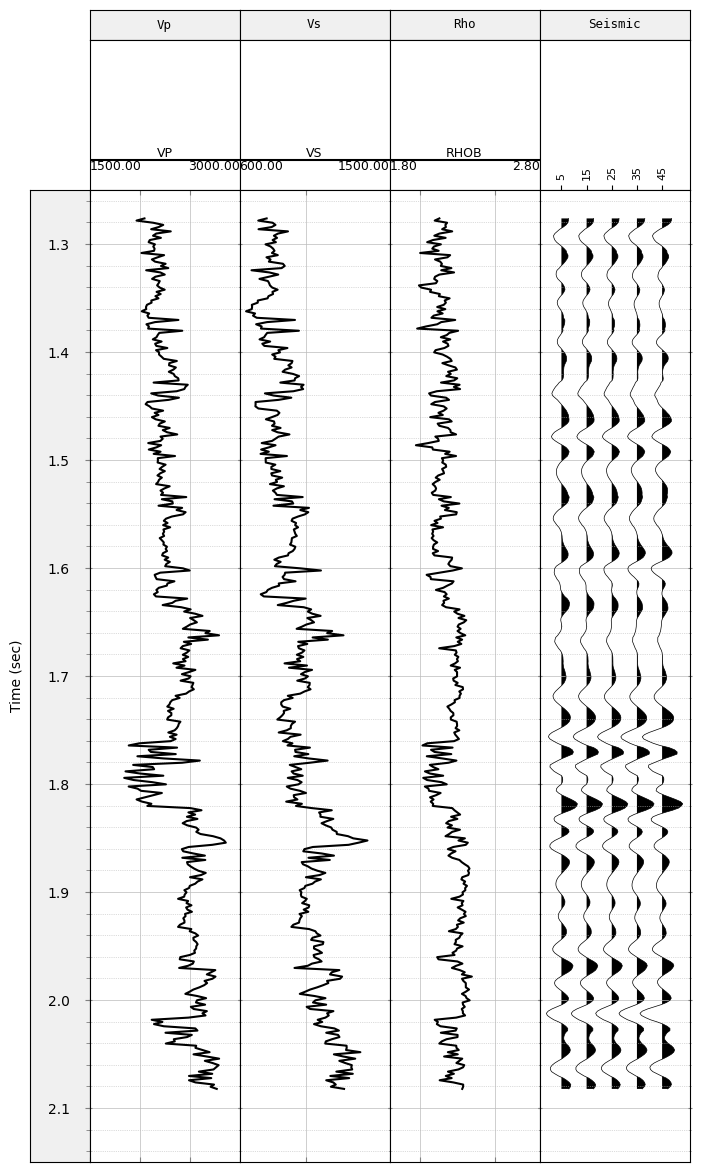

In [1]:
import lasio
import matplotlib.pyplot as plt
from rokpy.visualization import Sheet
from rokpy.constants import PropertyTemplates
from rokpy.avo import AVOMethods, ricker, convolution_seis
import numpy as np
from rokpy.conversions import depth_to_time

# Read Las-file
lasfile = r".\\wellB.las"
las = lasio.read(lasfile)
vp_log = las.curvesdict['VP']
vs_log = las.curvesdict['VS']
rho_log = las.curvesdict['RHOB']


# Define PropertyTemplates (required for tracks)
templates = PropertyTemplates()
templates.PVelocity.plot_range  = (1500, 3000)
templates.SVelocity.plot_range = (600, 1500)
templates.Density.plot_range = (1.8, 2.8)

# Define time sampling interval
dt = 0.002

# Define wavelet
w, _ = ricker(fdom=25, dt=dt, length=0.15)

# Make Time-Depth relation (TDR)
time_log = depth_to_time(las.depth_m, vp_log.data)

# Resample logs into a regular grid (required for convolution)
time_regular = np.arange(time_log[0], time_log[-1], dt)
vp_regular = np.interp(time_regular, time_log, vp_log.data)
vs_regular = np.interp(time_regular, time_log, vs_log.data)
rho_regular = np.interp(time_regular, time_log, rho_log.data)

theta = [5, 15, 25, 35, 45] #incident angles in degree
rpp = AVOMethods.aki_richards(vp_regular, vs_regular, rho_regular, theta)
seis = convolution_seis(rpp, w, dt)


# Define Log Sheet
sheet = plt.figure(FigureClass=Sheet, figsize=(6, 12))
sheet.set_depth_range(1.250,2.150)  # in sec
sheet.set_depth_label("Time","sec")

# Add tracks to the sheet
vp_tr = sheet.add_track(templates.PVelocity)
vs_tr = sheet.add_track(templates.SVelocity)
ro_tr = sheet.add_track(templates.Density)
seis_tr = sheet.add_track(templates.Seismic)

# # Disply each logs on the corresponding tracks
vp_tr.plot(time_regular, vp_regular, label=vp_log.mnemonic)
vs_tr.plot(time_regular, vs_regular, label=vs_log.mnemonic)
ro_tr.plot(time_regular, rho_regular, label=rho_log.mnemonic)
seis_tr.wiggle(seis, time_regular, theta, scale=2, color='black', fill_color='black', linewidth=0.5)
